In [4]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split 

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])


In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [8]:
X = df.drop(columns =['Survived'])
y = df['Survived']

In [9]:
X_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [10]:
X_train


,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [11]:
X_train['imputed_age'] = X_train['Age']
x_test['imputed_age'] = x_test['Age']

In [12]:
x_test.tail()

,Age,Fare,imputed_age
433,17.0,7.1250,17.0
773,NaN,7.2250,NaN
25,38.0,31.3875,38.0
84,17.0,10.5000,17.0
10,4.0,16.7000,4.0


In [14]:
X_train['imputed_age'][X_train['imputed_age'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
x_test['imputed_age'][x_test['imputed_age'].isnull()] = X_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

In [15]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([39.  , 17.  , 23.  , 34.  , 31.  , 56.  , 33.  , 10.  , 24.  ,
       40.5 ,  2.  , 18.  , 22.  , 29.  , 22.  , 32.5 , 30.  , 28.  ,
       29.  ,  9.  , 50.  ,  9.  , 23.  , 62.  , 36.  , 31.  , 30.  ,
       58.  , 36.  , 43.  , 24.  , 32.  , 14.  , 24.  , 27.  ,  8.  ,
       22.  , 48.  , 18.  ,  4.  , 55.5 , 48.  , 24.  ,  1.  , 54.  ,
       32.5 , 46.  , 18.  , 22.  , 30.  ,  4.  , 33.  , 16.  , 19.  ,
       38.  , 20.  , 34.  , 42.  , 27.  , 35.  , 27.  , 28.  , 30.  ,
       27.  , 39.  , 18.  , 24.  , 34.  , 28.  , 11.  , 24.  , 33.  ,
       26.  , 31.  , 36.  ,  4.  , 42.  , 28.  , 24.  , 27.  , 35.  ,
       30.  , 58.  , 31.  ,  0.42, 36.  , 45.  , 50.  ,  2.  , 45.  ,
       16.  , 18.  , 42.  , 60.  , 20.  ,  2.  ,  2.  , 33.  ,  0.67,
       34.  , 45.  , 15.  ,  3.  , 45.5 , 24.  , 19.  , 29.  , 20.  ,
       38.  , 52.  , 16.  , 39.  , 28.5 , 28.  , 19.  , 51.  , 48.  ,
       40.  , 37.  , 47.  , 22.  , 35.  , 14.  , 19.  , 17.  , 30.  ,
       28.  ,  7.  ,

In [16]:
X_train['Age'].isnull().sum()

140

In [17]:
X_train

,Age,Fare,imputed_age
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,44.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/2903959131.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/2903959131.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to 

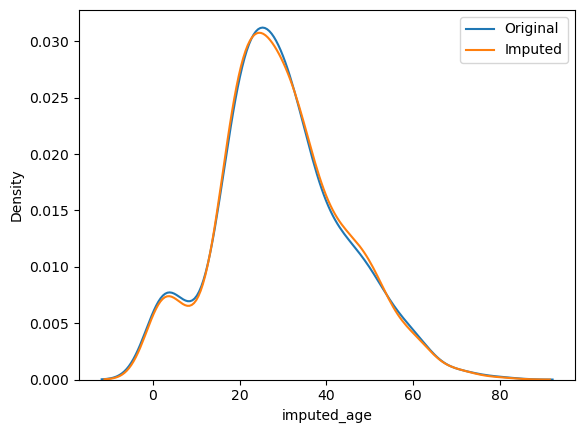

In [20]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['imputed_age'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [22]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['imputed_age'].var())

Original variable variance:  210.2517072477438
Variance after random imputation:  206.49863314824006


In [23]:
X_train[['Fare', 'Age', 'imputed_age']].cov()

,Fare,Age,imputed_age
Fare,2700.831981,71.580633,60.457250
Age,71.580633,210.251707,210.251707
imputed_age,60.457250,210.251707,206.498633


<Axes: >

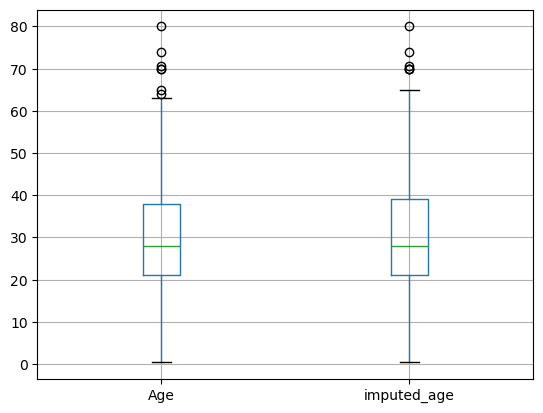

In [24]:
X_train[['Age', 'imputed_age']].boxplot()

In [25]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

NameError: name 'observation' is not defined

In [26]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [27]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [28]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [29]:

X = data
y = data['SalePrice']

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [31]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [32]:

X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
301,TA,TA,267000,TA,TA
104,TA,TA,169500,TA,TA
787,NaN,TA,233000,TA,NaN
272,Gd,TA,290000,TA,Gd
986,NaN,Fa,117000,Fa,NaN


In [33]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/856878696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/856878696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/

In [34]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [35]:
temp


,original,imputed
TA,0.951087,0.951199
Fa,0.032609,0.031678
Gd,0.011775,0.012842
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [36]:

temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.491143,0.645342
TA,0.405797,0.529742
Fa,0.043478,0.060606
Ex,0.033816,0.042649
Po,0.025765,0.032548


/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/416271417.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/416271417.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seabor

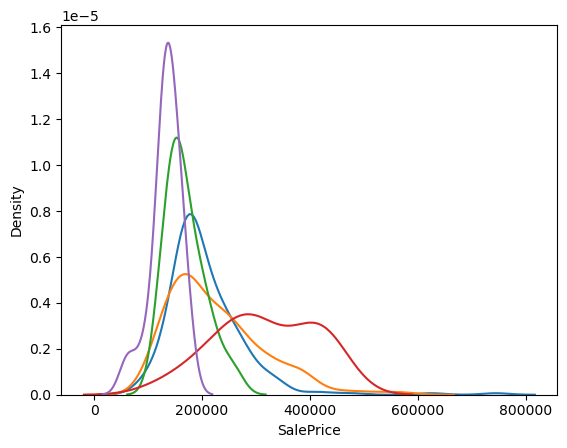

In [37]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()


/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/1048611703.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/_8/nbv35c4x7_s7llqh31gw802c0000gn/T/ipykernel_11990/1048611703.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed

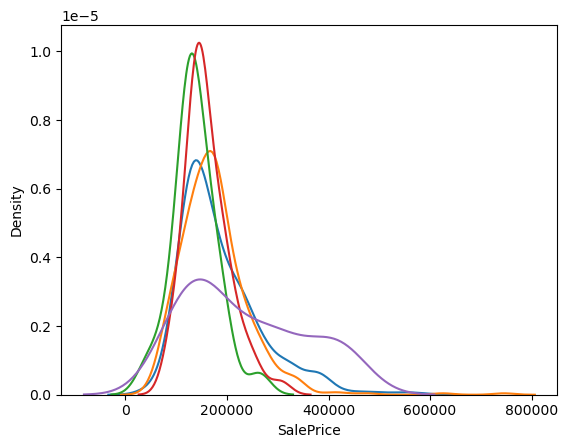

In [38]:

for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()
